# 타이타닉 데이터 기초 분석

- 데이터: `data/titanic/train_and_test2.csv`
- 내용: 결측치 / 중복값 / 이상치 확인 및 시각화


## 1. 데이터 불러오기

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

file_path = "data/titanic/train_and_test2.csv"

df = pd.read_csv(file_path)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

file_path = "data/titanic/train_and_test2.csv"

df = pd.read_csv(file_path)

## 2. 데이터 기본 정보 확인

In [2]:
print("=" * 60)
print("1. 데이터 기본 정보")
print("=" * 60)

print("\n데이터 크기:")
print(df.shape)

print("\n컬럼 이름:")
print(df.columns.tolist())

print("\n앞의 5개 데이터:")
print(df.head())

print("\n데이터 타입:")
print(df.dtypes)

1. 데이터 기본 정보

데이터 크기:
(1309, 28)

컬럼 이름:
['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

앞의 5개 데이터:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0      

## 3. 결측치 확인

In [3]:
print("=" * 60)
print("2. 결측치 확인")
print("=" * 60)

missing_count = df.isnull().sum()
missing_percent = df.isnull().sum() / len(df) * 100

missing_df = pd.DataFrame({
    "결측치 개수": missing_count,
    "결측치 비율(%)": missing_percent
})

missing_df = missing_df[missing_df["결측치 개수"] > 0]

print(missing_df)

2. 결측치 확인
          결측치 개수  결측치 비율(%)
Embarked       2   0.152788


## 4. 결측치 시각화

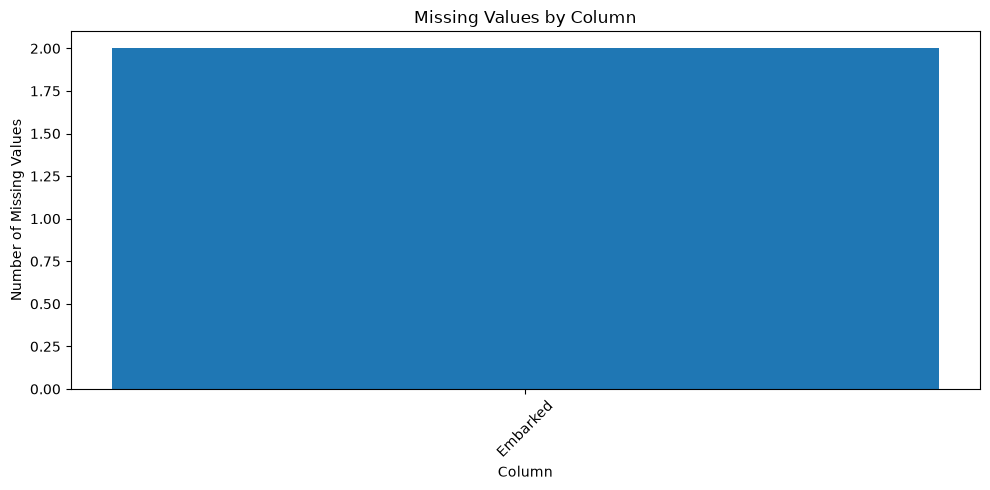

In [4]:
if len(missing_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_df.index, missing_df["결측치 개수"])
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("결측치가 없습니다.")

## 5. 중복값 확인

In [5]:
print("=" * 60)
print("3. 중복값 확인")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("전체 행 수 :", len(df))
print("중복 행 수 :", duplicate_count)

3. 중복값 확인
전체 행 수 : 1309
중복 행 수 : 0


## 6. 중복값 시각화

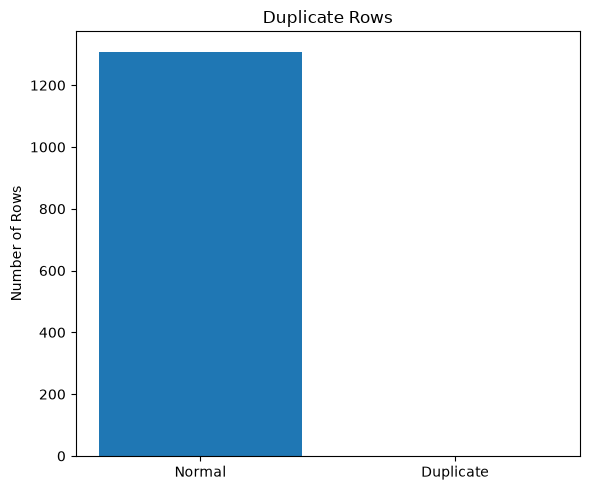

In [6]:
normal_count = len(df) - duplicate_count

plt.figure(figsize=(6, 5))
plt.bar(["Normal", "Duplicate"], [normal_count, duplicate_count])
plt.title("Duplicate Rows")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.show()

## 7. 숫자형 데이터 확인

In [7]:
print("=" * 60)
print("4. 숫자형 변수 확인")
print("=" * 60)

numeric_columns = df.select_dtypes(include="number").columns
print(numeric_columns.tolist())

4. 숫자형 변수 확인
['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']


## 8. 이상치 확인 (IQR 방법)

In [8]:
print("=" * 60)
print("5. 이상치 확인 (IQR 방법)")
print("=" * 60)

outlier_result = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_result[column] = len(outliers)

outlier_df = pd.DataFrame.from_dict(
    outlier_result,
    orient="index",
    columns=["이상치 개수"]
)

outlier_df = outlier_df.sort_values("이상치 개수", ascending=False)
print(outlier_df)

5. 이상치 확인 (IQR 방법)
             이상치 개수
Parch           307
Fare            171
Age             101
sibsp            57
Sex               0
zero              0
zero.1            0
zero.2            0
zero.3            0
zero.4            0
zero.5            0
Passengerid       0
zero.6            0
zero.7            0
zero.8            0
zero.9            0
zero.10           0
zero.11           0
zero.12           0
zero.13           0
zero.14           0
Pclass            0
zero.15           0
zero.16           0
Embarked          0
zero.17           0
zero.18           0
2urvived          0


## 9. 이상치 개수 시각화

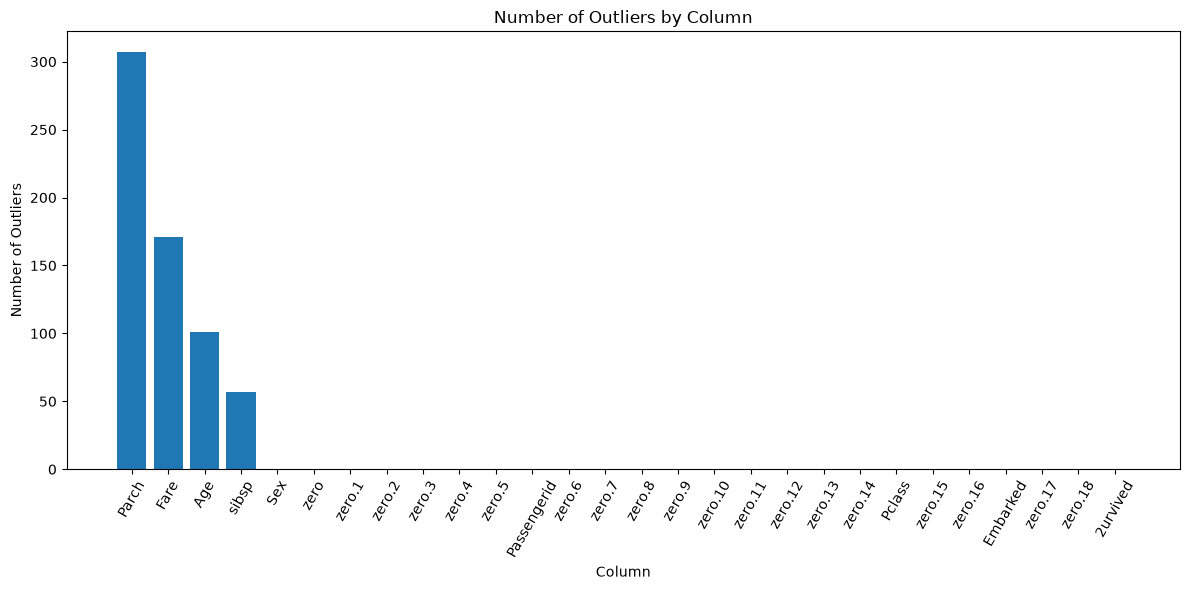

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(outlier_df.index, outlier_df["이상치 개수"])
plt.title("Number of Outliers by Column")
plt.xlabel("Column")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 10. 숫자형 변수 Box Plot

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


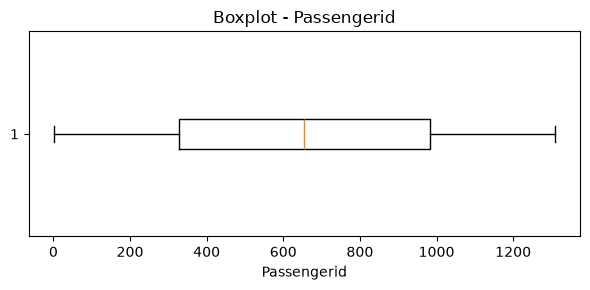

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


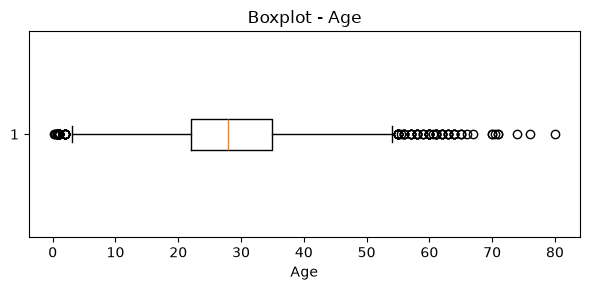

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


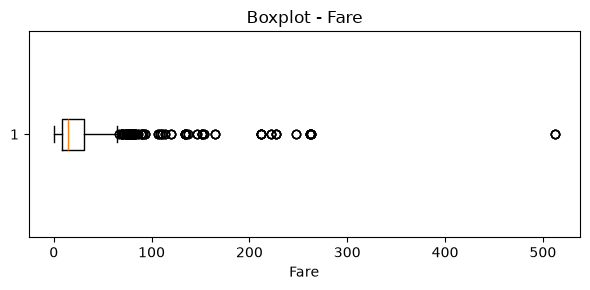

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


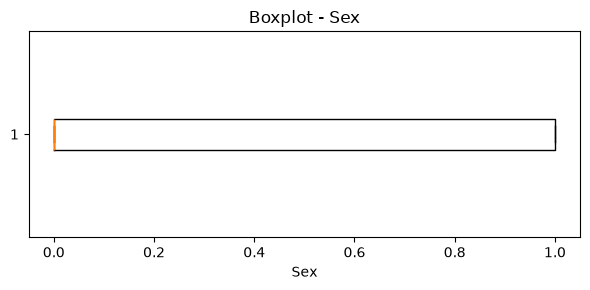

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


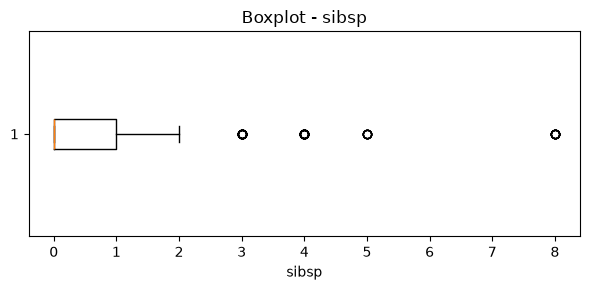

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


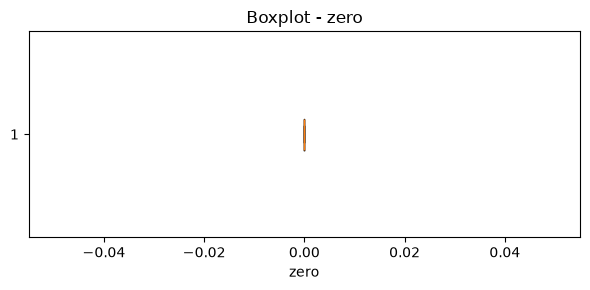

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


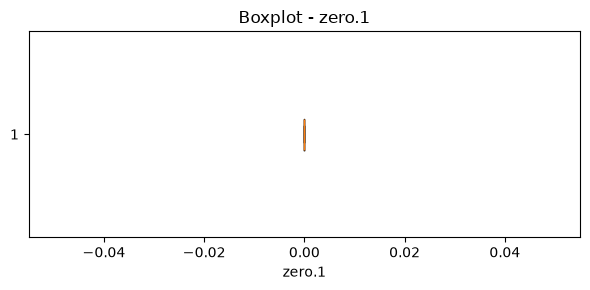

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


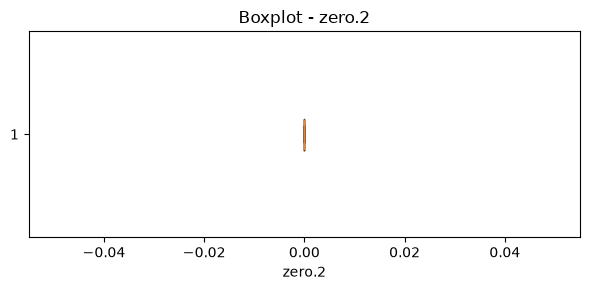

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


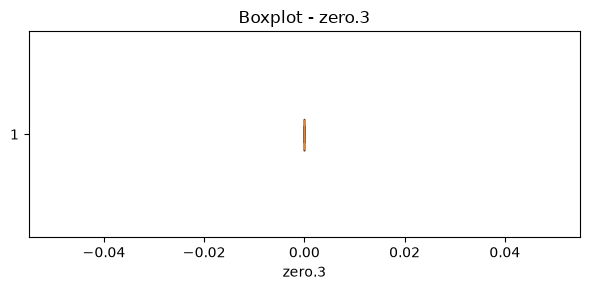

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


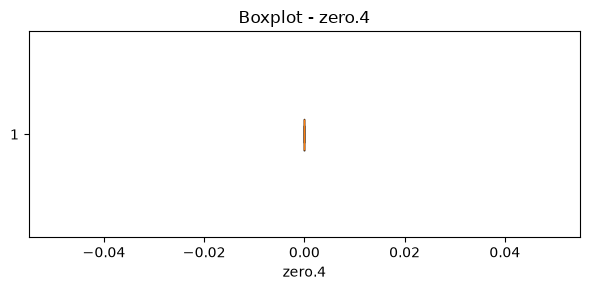

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


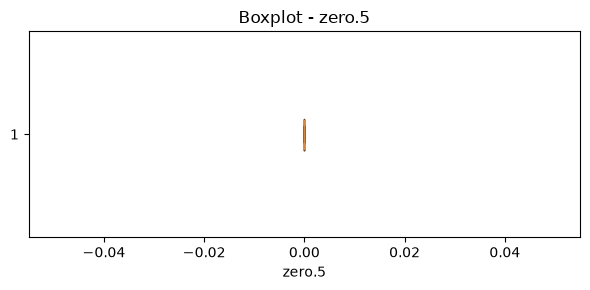

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


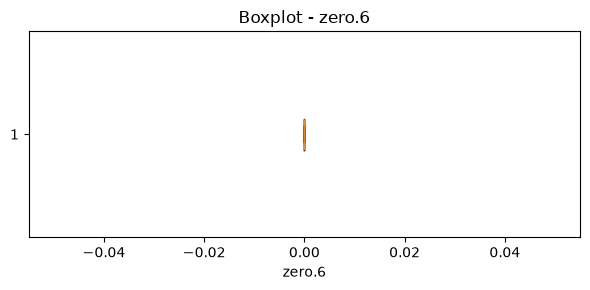

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


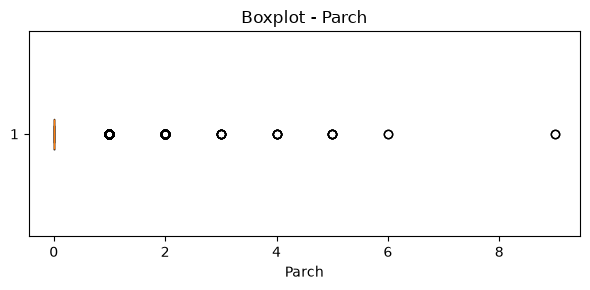

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


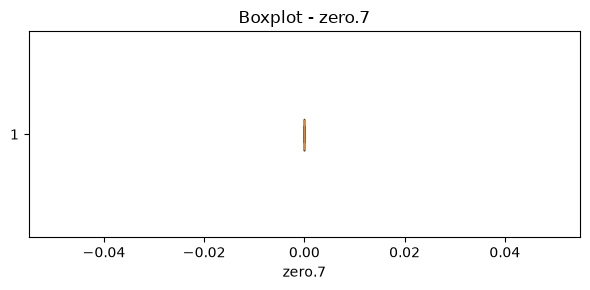

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


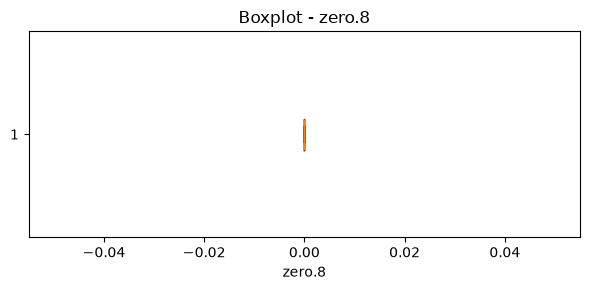

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


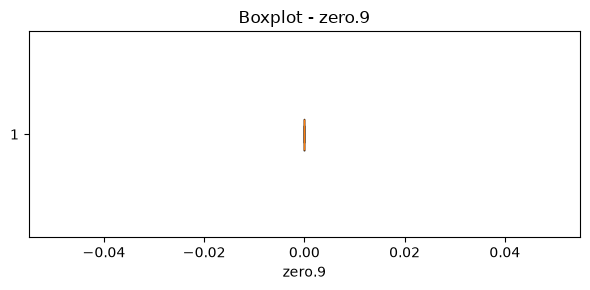

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


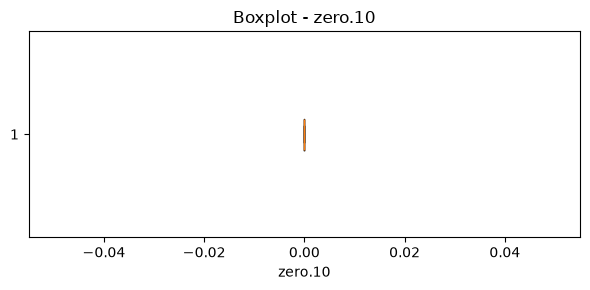

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


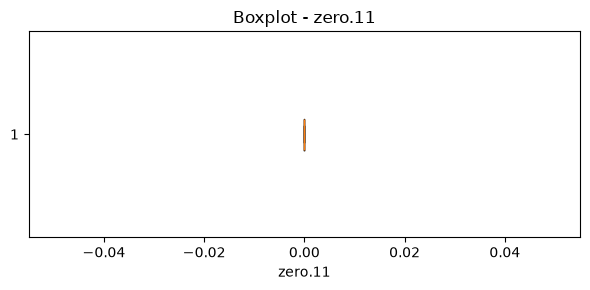

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


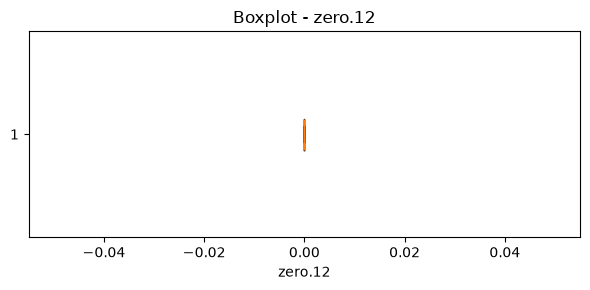

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


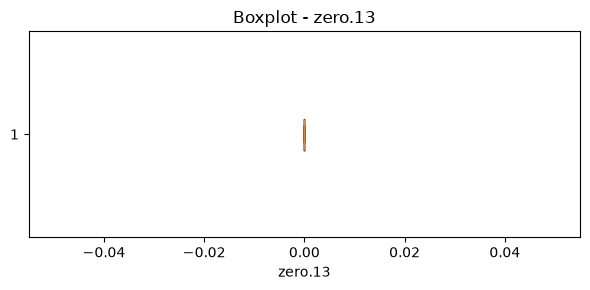

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


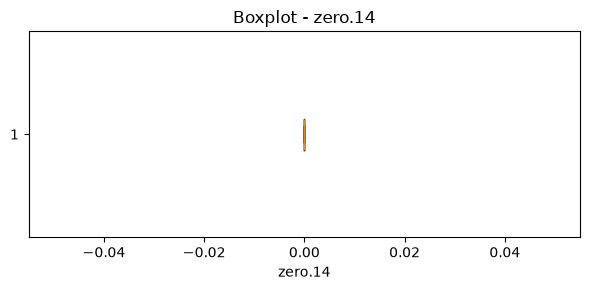

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


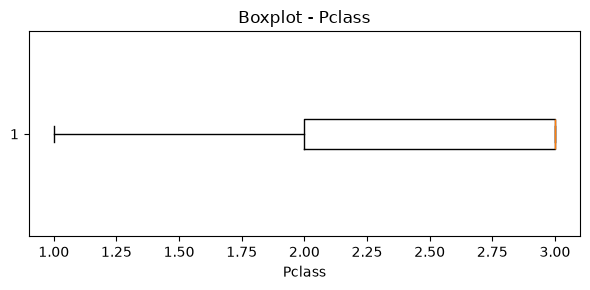

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


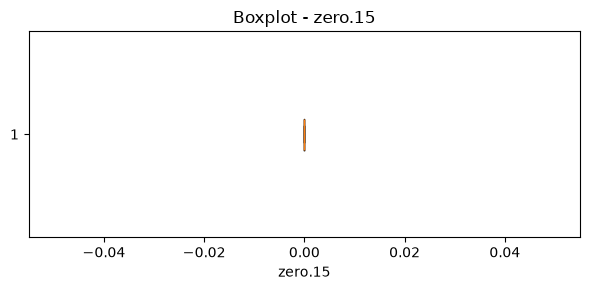

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


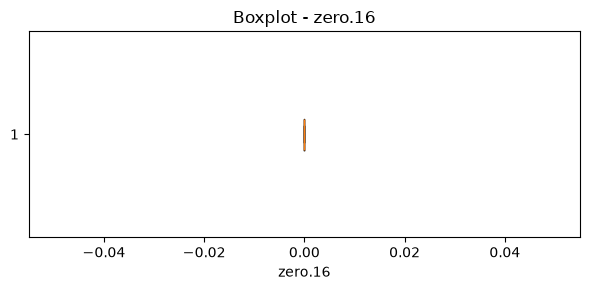

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


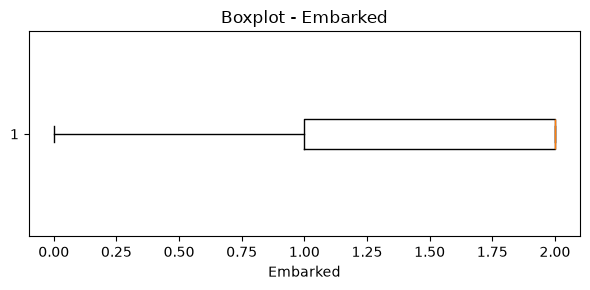

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


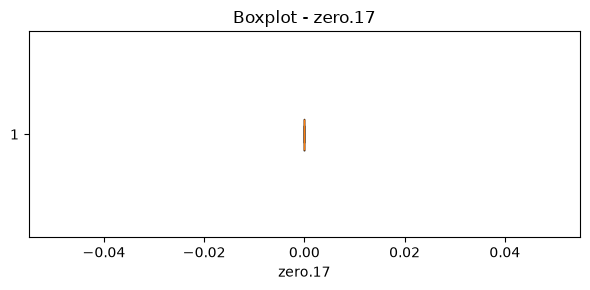

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


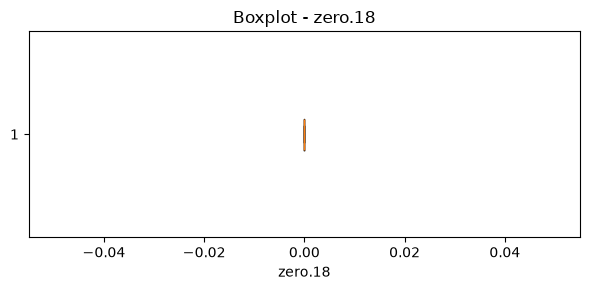

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_5936\1843381361.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


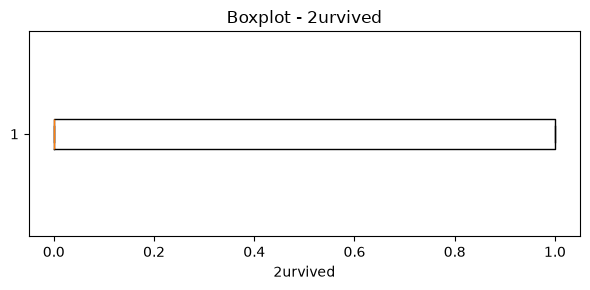

In [10]:
for column in numeric_columns:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Boxplot - {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## 실습 1. 데이터 진단만 하기

In [11]:
# =========================================================
# 실습 1. 데이터 진단만 하기
# =========================================================

print("데이터 크기:", df.shape)

# 자료형
print("\n[자료형]")
display(df.dtypes.to_frame("dtype"))

# 결측치
missing = pd.DataFrame({
    "결측치 개수": df.isna().sum(),
    "결측치 비율(%)": df.isna().mean() * 100
})

missing = missing[missing["결측치 개수"] > 0]

print("\n[결측치]")
display(missing)

# 중복값
print("\n[중복 행]")
print("중복 행 수:", df.duplicated().sum())

# 숫자형 변수 요약
print("\n[숫자형 변수 요약]")
display(df.describe().T)

데이터 크기: (1309, 28)

[자료형]


,dtype
Passengerid,int64
Age,float64
Fare,float64
Sex,int64
sibsp,int64
zero,int64
zero.1,int64
zero.2,int64
zero.3,int64
zero.4,int64



[결측치]


,결측치 개수,결측치 비율(%)
Embarked,2,0.152788



[중복 행]
중복 행 수: 0

[숫자형 변수 요약]


,count,mean,std,min,25%,50%,75%,max
Passengerid,1309.0,655.000000,378.020061,1.00,328.0000,655.0000,982.000,1309.0000
Age,1309.0,29.503186,12.905241,0.17,22.0000,28.0000,35.000,80.0000
Fare,1309.0,33.281086,51.741500,0.00,7.8958,14.4542,31.275,512.3292
Sex,1309.0,0.355997,0.478997,0.00,0.0000,0.0000,1.000,1.0000
sibsp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
zero,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.1,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.2,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.3,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.4,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000


In [12]:
# Embarked가 결측치인 행만 확인
df[df["Embarked"].isna()][
    ["Passengerid", "Age", "Fare", "Sex", "Pclass", "Embarked", "2urvived"]
]

,Passengerid,Age,Fare,Sex,Pclass,Embarked,2urvived
61,62,38.0,80.0,1,1,NaN,1
829,830,62.0,80.0,1,1,NaN,1


In [13]:
# Embarked에 어떤 값들이 들어 있는지 확인
df["Embarked"].value_counts(dropna=False).sort_index()

Embarked
0.0    270
1.0    123
2.0    914
NaN      2
Name: count, dtype: int64

In [14]:
# 원본 데이터 보호
df_test = df.copy()

# 비교 전 Age 평균과 표준편차
before_mean = df_test["Age"].mean()
before_std = df_test["Age"].std()

print("원래 Age 평균:", before_mean)
print("원래 Age 표준편차:", before_std)

원래 Age 평균: 29.50318563789152
원래 Age 표준편차: 12.905240585464622


In [15]:
# 학습용으로 Age 앞 5개 값을 결측치로 변경
df_test.loc[df_test.index[:5], "Age"] = pd.NA

print("만든 Age 결측치 수:", df_test["Age"].isna().sum())

만든 Age 결측치 수: 5


In [16]:
# ① 행 삭제 방식
df_drop = df_test.dropna(subset=["Age"])

drop_mean = df_drop["Age"].mean()
drop_std = df_drop["Age"].std()

print("[행 삭제]")
print("평균:", drop_mean)
print("표준편차:", drop_std)
print("데이터 개수:", len(df_drop))

[행 삭제]
평균: 29.49667944785276
표준편차: 12.92400349151392
데이터 개수: 1304


In [17]:
# ② 평균 대치 방식
df_fill = df_test.copy()

age_mean = df_fill["Age"].mean()

df_fill["Age"] = df_fill["Age"].fillna(age_mean)

fill_mean = df_fill["Age"].mean()
fill_std = df_fill["Age"].std()

print("[평균 대치]")
print("대치에 사용한 평균:", age_mean)
print("대치 후 평균:", fill_mean)
print("대치 후 표준편차:", fill_std)
print("데이터 개수:", len(df_fill))

[평균 대치]
대치에 사용한 평균: 29.49667944785276
대치 후 평균: 29.49667944785276
대치 후 표준편차: 12.899277998250671
데이터 개수: 1309


In [18]:
comparison = pd.DataFrame({
    "방법": ["원본", "행 삭제", "평균 대치"],
    "평균": [
        before_mean,
        drop_mean,
        fill_mean
    ],
    "표준편차": [
        before_std,
        drop_std,
        fill_std
    ],
    "데이터 개수": [
        len(df),
        len(df_drop),
        len(df_fill)
    ]
})

comparison

,방법,평균,표준편차,데이터 개수
0,원본,29.503186,12.905241,1309
1,행 삭제,29.496679,12.924003,1304
2,평균 대치,29.496679,12.899278,1309


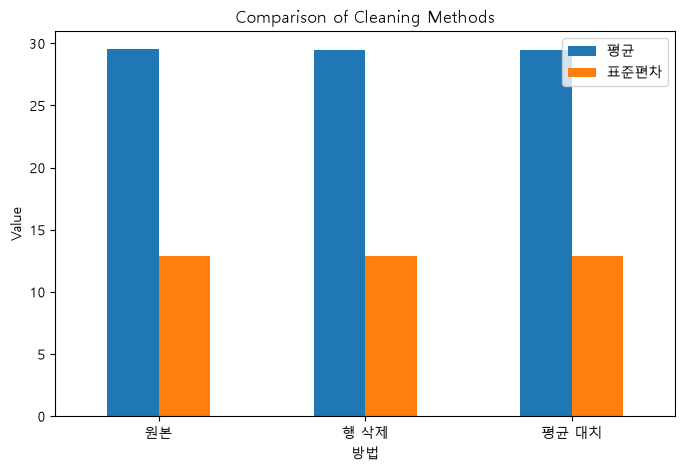

In [21]:
comparison.set_index("방법")[["평균", "표준편차"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparison of Cleaning Methods")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.show()

In [22]:
cleaning_log = pd.DataFrame([
    {
        "대상": "Embarked",
        "문제": "결측치 2개",
        "결정": "현재는 삭제하거나 대치하지 않음",
        "이유": "전체의 약 0.153%이며, 범주형 변수이므로 평균 대치가 적절하지 않음"
    },
    {
        "대상": "Age",
        "문제": "학습용 결측치 5개 생성",
        "결정": "행 삭제와 평균 대치를 각각 실험",
        "이유": "결측치 처리 방법에 따라 통계량이 어떻게 달라지는지 비교하기 위함"
    },
    {
        "대상": "Age - 행 삭제",
        "문제": "결측치가 있는 5개 행 제거",
        "결정": "실험용 처리",
        "이유": "데이터 수가 1309 → 1304로 감소하고 평균·표준편차가 변하는 것을 확인"
    },
    {
        "대상": "Age - 평균 대치",
        "문제": "결측치 5개",
        "결정": "현재 Age 평균으로 대치",
        "이유": "데이터 수는 유지되지만 표준편차가 감소하는 것을 확인"
    }
])

cleaning_log

,대상,문제,결정,이유
0,Embarked,결측치 2개,현재는 삭제하거나 대치하지 않음,"전체의 약 0.153%이며, 범주형 변수이므로 평균 대치가 적절하지 않음"
1,Age,학습용 결측치 5개 생성,행 삭제와 평균 대치를 각각 실험,결측치 처리 방법에 따라 통계량이 어떻게 달라지는지 비교하기 위함
2,Age - 행 삭제,결측치가 있는 5개 행 제거,실험용 처리,데이터 수가 1309 → 1304로 감소하고 평균·표준편차가 변하는 것을 확인
3,Age - 평균 대치,결측치 5개,현재 Age 평균으로 대치,데이터 수는 유지되지만 표준편차가 감소하는 것을 확인


In [23]:
# 원본 보존
df_original = df.copy()

# 결측치가 있는 행 확인
missing_rows = df_original[df_original["Embarked"].isna()]

missing_rows[
    ["Passengerid", "Age", "Fare", "Sex", "Pclass", "Embarked", "2urvived"]
]

,Passengerid,Age,Fare,Sex,Pclass,Embarked,2urvived
61,62,38.0,80.0,1,1,NaN,1
829,830,62.0,80.0,1,1,NaN,1


In [24]:
embarked_mean = df_original["Embarked"].mean()
embarked_median = df_original["Embarked"].median()
embarked_mode = df_original["Embarked"].mode()[0]
embarked_max = df_original["Embarked"].max()

print("평균값 :", embarked_mean)
print("중앙값 :", embarked_median)
print("최빈값 :", embarked_mode)
print("최대값 :", embarked_max)

평균값 : 1.4927314460596786
중앙값 : 2.0
최빈값 : 2.0
최대값 : 2.0


In [25]:
df_delete = df_original.dropna(subset=["Embarked"]).copy()

print("원본 행 수:", len(df_original))
print("삭제 후 행 수:", len(df_delete))

원본 행 수: 1309
삭제 후 행 수: 1307


In [26]:
df_mean = df_original.copy()

df_mean["Embarked"] = df_mean["Embarked"].fillna(
    df_mean["Embarked"].mean()
)

df_mean.loc[missing_rows.index, ["Passengerid", "Embarked"]]

,Passengerid,Embarked
61,62,1.492731
829,830,1.492731


In [27]:
df_median = df_original.copy()

df_median["Embarked"] = df_median["Embarked"].fillna(
    df_median["Embarked"].median()
)

df_median.loc[missing_rows.index, ["Passengerid", "Embarked"]]

,Passengerid,Embarked
61,62,2.0
829,830,2.0


In [28]:
df_mode = df_original.copy()

mode_value = df_mode["Embarked"].mode()[0]

df_mode["Embarked"] = df_mode["Embarked"].fillna(mode_value)

df_mode.loc[missing_rows.index, ["Passengerid", "Embarked"]]

,Passengerid,Embarked
61,62,2.0
829,830,2.0


In [29]:
df_max = df_original.copy()

max_value = df_max["Embarked"].max()

df_max["Embarked"] = df_max["Embarked"].fillna(max_value)

df_max.loc[missing_rows.index, ["Passengerid", "Embarked"]]

,Passengerid,Embarked
61,62,2.0
829,830,2.0


In [30]:
import numpy as np

# 결과가 매번 달라지지 않도록 시드 고정
np.random.seed(42)

df_random = df_original.copy()

available_values = df_random["Embarked"].dropna().values

missing_indices = df_random[df_random["Embarked"].isna()].index

random_values = np.random.choice(
    available_values,
    size=len(missing_indices),
    replace=True
)

df_random.loc[missing_indices, "Embarked"] = random_values

df_random.loc[
    missing_indices,
    ["Passengerid", "Embarked"]
]

,Passengerid,Embarked
61,62,0.0
829,830,2.0


In [31]:
df_infer = df_original.copy()

for idx in df_infer[df_infer["Embarked"].isna()].index:

    pclass = df_infer.loc[idx, "Pclass"]
    sex = df_infer.loc[idx, "Sex"]

    # 같은 Pclass + Sex인 승객들
    similar = df_infer[
        (df_infer["Pclass"] == pclass) &
        (df_infer["Sex"] == sex) &
        (df_infer["Embarked"].notna())
    ]

    inferred_value = similar["Embarked"].mode()[0]

    df_infer.loc[idx, "Embarked"] = inferred_value

df_infer.loc[
    missing_rows.index,
    ["Passengerid", "Age", "Fare", "Sex", "Pclass", "Embarked"]
]

,Passengerid,Age,Fare,Sex,Pclass,Embarked
61,62,38.0,80.0,1,1,0.0
829,830,62.0,80.0,1,1,0.0


In [32]:
result = pd.DataFrame({
    "방법": [
        "행 삭제",
        "평균값",
        "중앙값",
        "최빈값",
        "최대값",
        "랜덤값",
        "유추값"
    ],

    "Passenger 62": [
        "삭제",
        df_mean.loc[61, "Embarked"],
        df_median.loc[61, "Embarked"],
        df_mode.loc[61, "Embarked"],
        df_max.loc[61, "Embarked"],
        df_random.loc[61, "Embarked"],
        df_infer.loc[61, "Embarked"]
    ],

    "Passenger 830": [
        "삭제",
        df_mean.loc[829, "Embarked"],
        df_median.loc[829, "Embarked"],
        df_mode.loc[829, "Embarked"],
        df_max.loc[829, "Embarked"],
        df_random.loc[829, "Embarked"],
        df_infer.loc[829, "Embarked"]
    ]
})

result

,방법,Passenger 62,Passenger 830
0,행 삭제,삭제,삭제
1,평균값,1.492731,1.492731
2,중앙값,2.0,2.0
3,최빈값,2.0,2.0
4,최대값,2.0,2.0
5,랜덤값,0.0,2.0
6,유추값,0.0,0.0


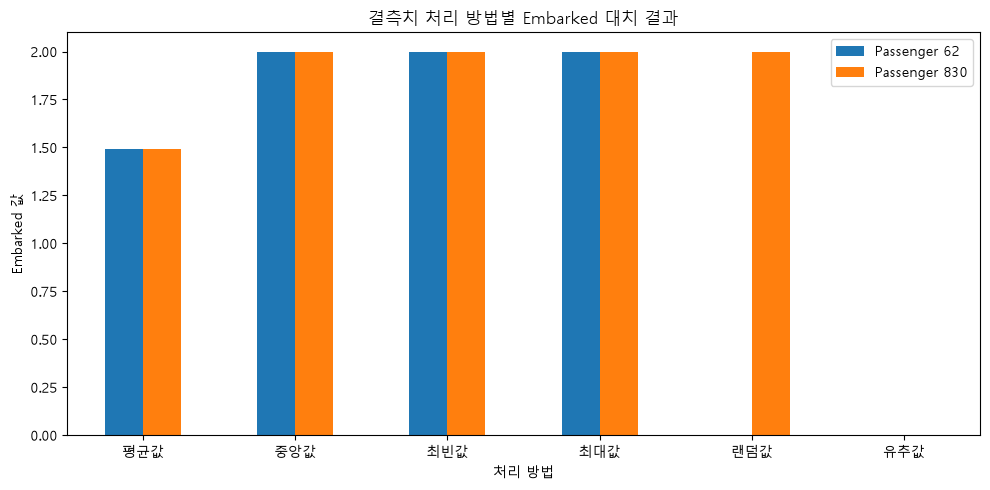

In [33]:
plot_result = pd.DataFrame({
    "방법": [
        "평균값",
        "중앙값",
        "최빈값",
        "최대값",
        "랜덤값",
        "유추값"
    ],

    "Passenger 62": [
        df_mean.loc[61, "Embarked"],
        df_median.loc[61, "Embarked"],
        df_mode.loc[61, "Embarked"],
        df_max.loc[61, "Embarked"],
        df_random.loc[61, "Embarked"],
        df_infer.loc[61, "Embarked"]
    ],

    "Passenger 830": [
        df_mean.loc[829, "Embarked"],
        df_median.loc[829, "Embarked"],
        df_mode.loc[829, "Embarked"],
        df_max.loc[829, "Embarked"],
        df_random.loc[829, "Embarked"],
        df_infer.loc[829, "Embarked"]
    ]
})

plot_result.set_index("방법").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("결측치 처리 방법별 Embarked 대치 결과")
plt.xlabel("처리 방법")
plt.ylabel("Embarked 값")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# 데이터 크기
print("데이터 크기:", df.shape)

# 앞부분
display(df.head())

# 기초통계
display(df.describe().T)

# 결측치
display(
    pd.DataFrame({
        "결측치 수": df.isna().sum(),
        "결측치 비율(%)": df.isna().mean() * 100
    })
)

# 중복
print("중복 행:", df.duplicated().sum())

데이터 크기: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


,count,mean,std,min,25%,50%,75%,max
Passengerid,1309.0,655.000000,378.020061,1.00,328.0000,655.0000,982.000,1309.0000
Age,1309.0,29.503186,12.905241,0.17,22.0000,28.0000,35.000,80.0000
Fare,1309.0,33.281086,51.741500,0.00,7.8958,14.4542,31.275,512.3292
Sex,1309.0,0.355997,0.478997,0.00,0.0000,0.0000,1.000,1.0000
sibsp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
zero,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.1,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.2,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.3,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.4,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000


,결측치 수,결측치 비율(%)
Passengerid,0,0.000000
Age,0,0.000000
Fare,0,0.000000
Sex,0,0.000000
sibsp,0,0.000000
zero,0,0.000000
zero.1,0,0.000000
zero.2,0,0.000000
zero.3,0,0.000000
zero.4,0,0.000000


중복 행: 0


In [35]:
# 각 열의 고유값 개수 확인
unique_counts = df.nunique()

unique_counts.sort_values()

zero.1            1
zero.2            1
zero              1
zero.7            1
zero.6            1
zero.5            1
zero.4            1
zero.3            1
zero.9            1
zero.8            1
zero.15           1
zero.14           1
zero.13           1
zero.12           1
zero.11           1
zero.10           1
zero.18           1
zero.17           1
zero.16           1
2urvived          2
Sex               2
Pclass            3
Embarked          3
sibsp             7
Parch             8
Age              98
Fare            281
Passengerid    1309
dtype: int64

In [36]:
constant_columns = df.columns[df.nunique() <= 1]

print("값이 하나뿐인 열:")
print(constant_columns.tolist())

값이 하나뿐인 열:
['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18']


In [37]:
df_clean = df.copy()

df_clean = df_clean.drop(columns=constant_columns)

print("전처리 전:", df.shape)
print("전처리 후:", df_clean.shape)

전처리 전: (1309, 28)
전처리 후: (1309, 9)


In [38]:
df_clean = df_clean.rename(
    columns={"2urvived": "Survived"}
)

In [39]:
df_clean["Survived"].value_counts()

Survived
0    967
1    342
Name: count, dtype: int64

In [40]:
df_clean["Survived"].value_counts(normalize=True) * 100

Survived
0    73.873186
1    26.126814
Name: proportion, dtype: float64

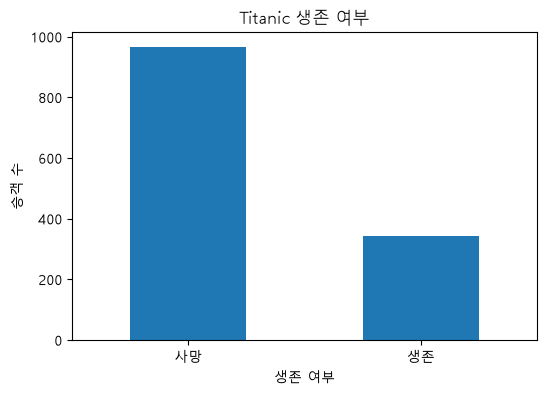

In [41]:
survival_counts = df_clean["Survived"].value_counts().sort_index()

survival_counts.index = ["사망", "생존"]

survival_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Titanic 생존 여부")
plt.xlabel("생존 여부")
plt.ylabel("승객 수")
plt.xticks(rotation=0)
plt.show()

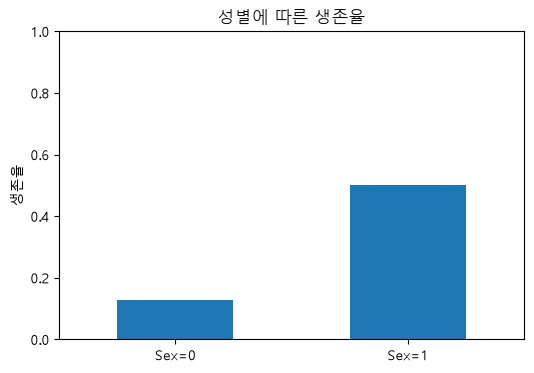

In [42]:
sex_survival = df_clean.groupby("Sex")["Survived"].mean()

sex_survival.index = ["Sex=0", "Sex=1"]

sex_survival.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("성별에 따른 생존율")
plt.ylabel("생존율")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

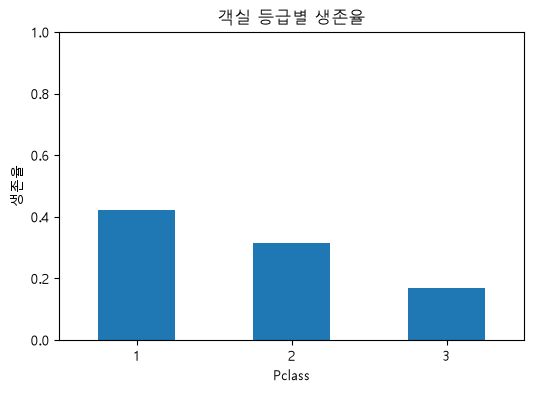

In [43]:
class_survival = (
    df_clean
    .groupby("Pclass")["Survived"]
    .mean()
)

class_survival.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("객실 등급별 생존율")
plt.xlabel("Pclass")
plt.ylabel("생존율")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

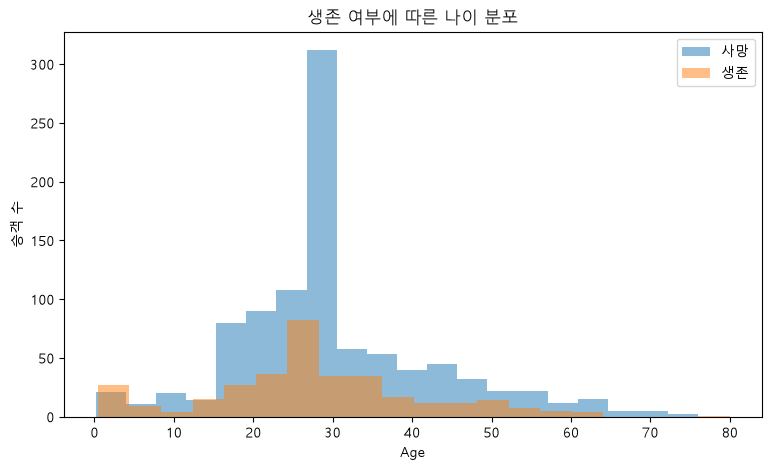

In [44]:
survived_age = df_clean[
    df_clean["Survived"] == 1
]["Age"]

dead_age = df_clean[
    df_clean["Survived"] == 0
]["Age"]

plt.figure(figsize=(9, 5))

plt.hist(
    dead_age.dropna(),
    bins=20,
    alpha=0.5,
    label="사망"
)

plt.hist(
    survived_age.dropna(),
    bins=20,
    alpha=0.5,
    label="생존"
)

plt.title("생존 여부에 따른 나이 분포")
plt.xlabel("Age")
plt.ylabel("승객 수")

plt.legend()
plt.show()

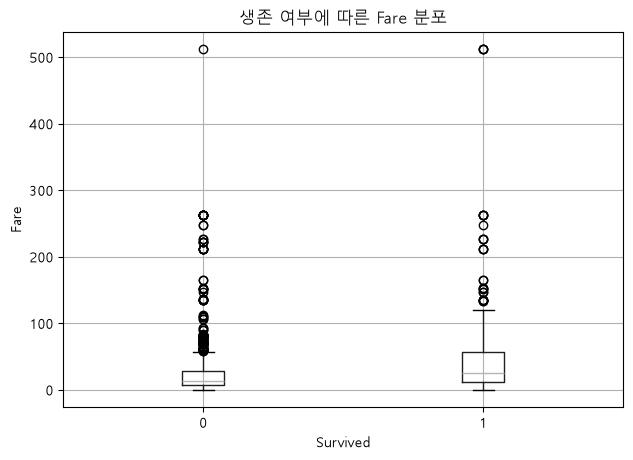

In [45]:
df_clean.boxplot(
    column="Fare",
    by="Survived",
    figsize=(7, 5)
)

plt.title("생존 여부에 따른 Fare 분포")
plt.suptitle("")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

In [46]:
selected_columns = [
    "Age",
    "Fare",
    "Sex",
    "sibsp",
    "Parch",
    "Pclass",
    "Embarked",
    "Survived"
]

correlation = df_clean[selected_columns].corr()

correlation

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
Age,1.000000,0.178182,-0.053663,-0.189972,-0.125851,-0.377908,-0.065125,-0.055862
Fare,0.178182,1.000000,0.185681,0.160349,0.221635,-0.558683,-0.239212,0.173786
Sex,-0.053663,0.185681,1.000000,0.109609,0.213125,-0.124617,-0.099408,0.404020
sibsp,-0.189972,0.160349,0.109609,1.000000,0.373587,0.060832,0.066055,-0.014375
Parch,-0.125851,0.221635,0.213125,0.373587,1.000000,0.018322,0.045216,0.054908
Pclass,-0.377908,-0.558683,-0.124617,0.060832,0.018322,1.000000,0.187349,-0.244686
Embarked,-0.065125,-0.239212,-0.099408,0.066055,0.045216,0.187349,1.000000,-0.093225
Survived,-0.055862,0.173786,0.404020,-0.014375,0.054908,-0.244686,-0.093225,1.000000


In [47]:
correlation["Survived"].sort_values(
    ascending=False
)

Survived    1.000000
Sex         0.404020
Fare        0.173786
Parch       0.054908
sibsp      -0.014375
Age        -0.055862
Embarked   -0.093225
Pclass     -0.244686
Name: Survived, dtype: float64

In [48]:
python -m pip install seaborn scikit-learn

SyntaxError: invalid syntax (3221799966.py, line 1)

In [49]:
import seaborn as sns

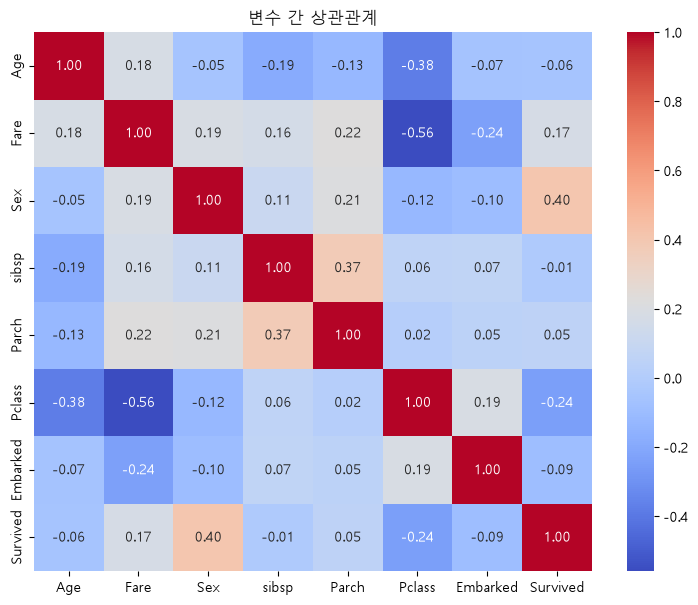

In [50]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("변수 간 상관관계")
plt.show()

In [51]:
features = [
    "Age",
    "Fare",
    "Sex",
    "sibsp",
    "Parch",
    "Pclass",
    "Embarked"
]

X = df_clean[features].copy()

y = df_clean["Survived"].copy()

In [52]:
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

In [53]:
X.isna().sum()

Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    0
dtype: int64

In [54]:
X = pd.get_dummies(
    X,
    columns=["Embarked", "Pclass"],
    drop_first=True
)

X.head()

,Age,Fare,Sex,sibsp,Parch,Embarked_1.0,Embarked_2.0,Pclass_2,Pclass_3
0,22.0,7.2500,0,1,0,False,True,False,True
1,38.0,71.2833,1,1,0,False,False,False,False
2,26.0,7.9250,1,0,0,False,True,False,True
3,35.0,53.1000,1,1,0,False,True,False,False
4,35.0,8.0500,0,0,0,False,True,False,True


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)

학습 데이터: (1047, 9)
테스트 데이터: (262, 9)


In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LogisticRegression(max_iter=1000)

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
);

In [58]:
print("모델 학습 완료")
print(model)

모델 학습 완료
LogisticRegression(max_iter=1000)


In [59]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0]


In [60]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7442748091603053


In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[171  23]
 [ 44  24]]


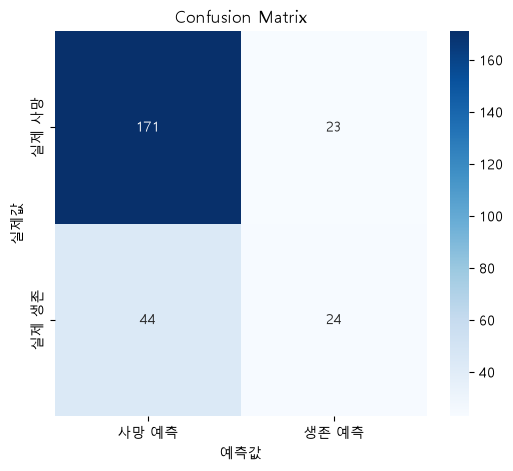

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["사망 예측", "생존 예측"],
    yticklabels=["실제 사망", "실제 생존"]
)

plt.title("Confusion Matrix")
plt.xlabel("예측값")
plt.ylabel("실제값")

plt.show()

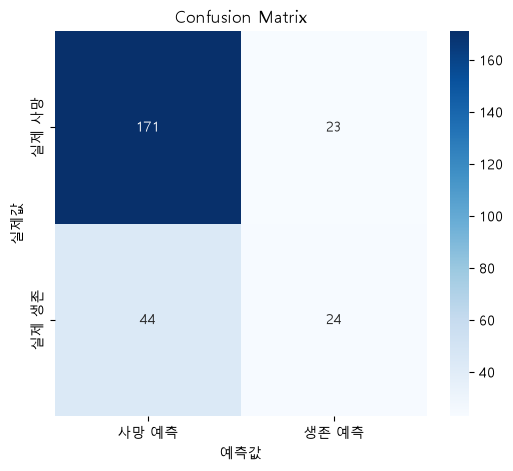

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["사망 예측", "생존 예측"],
    yticklabels=["실제 사망", "실제 생존"]
)

plt.title("Confusion Matrix")
plt.xlabel("예측값")
plt.ylabel("실제값")

plt.show()

In [64]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["사망", "생존"]
    )
)

              precision    recall  f1-score   support

          사망       0.80      0.88      0.84       194
          생존       0.51      0.35      0.42        68

    accuracy                           0.74       262
   macro avg       0.65      0.62      0.63       262
weighted avg       0.72      0.74      0.73       262



In [65]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Logistic Regression 정확도:", accuracy)
print("Baseline 정확도:", baseline_accuracy)

Logistic Regression 정확도: 0.7442748091603053
Baseline 정확도: 0.7404580152671756


In [66]:
importance = pd.DataFrame({
    "변수": X.columns,
    "계수": model.coef_[0]
})

importance = importance.sort_values(
    "계수",
    ascending=False
)

importance

,변수,계수
2,Sex,1.893496
1,Fare,-0.000308
5,Embarked_1.0,-0.009210
4,Parch,-0.018007
0,Age,-0.031147
6,Embarked_2.0,-0.125392
3,sibsp,-0.156610
7,Pclass_2,-0.572022
8,Pclass_3,-1.599977


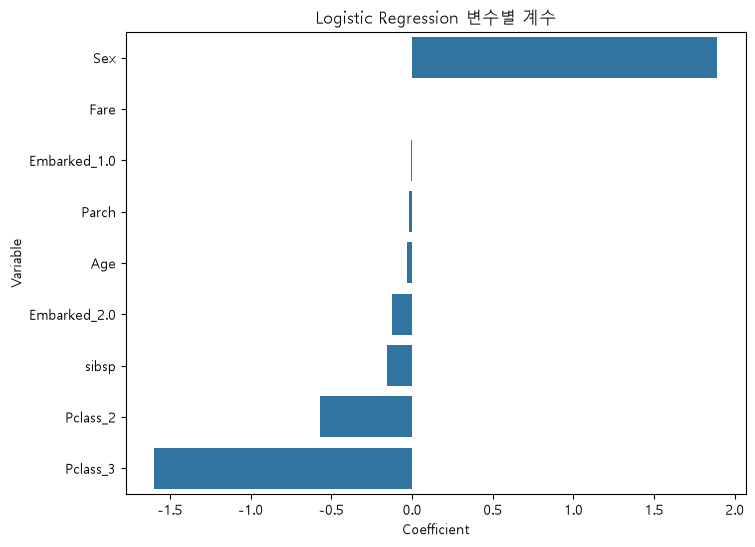

In [67]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=importance,
    x="계수",
    y="변수"
)

plt.title("Logistic Regression 변수별 계수")
plt.xlabel("Coefficient")
plt.ylabel("Variable")

plt.show()

In [68]:
prediction_result = pd.DataFrame({
    "실제값": y_test.values,
    "예측값": y_pred
})

prediction_result["정답여부"] = (
    prediction_result["실제값"]
    == prediction_result["예측값"]
)

prediction_result.head(20)

,실제값,예측값,정답여부
0,0,1,False
1,1,0,False
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,1,False
7,1,0,False
8,1,0,False
9,0,0,True


In [69]:
prediction_result[
    prediction_result["정답여부"] == False
].head(20)

,실제값,예측값,정답여부
0,0,1,False
1,1,0,False
6,0,1,False
7,1,0,False
8,1,0,False
15,0,1,False
21,1,0,False
23,0,1,False
25,0,1,False
26,1,0,False


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

scaled_model.fit(X_train, y_train)

print("표준화 Logistic Regression 학습 완료")

표준화 Logistic Regression 학습 완료


In [71]:
y_pred_scaled = scaled_model.predict(X_test)

print(y_pred_scaled[:20])

[1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0]


In [72]:
from sklearn.metrics import accuracy_score, classification_report

scaled_accuracy = accuracy_score(
    y_test,
    y_pred_scaled
)

print("기존 Logistic Regression:", accuracy)
print("표준화 Logistic Regression:", scaled_accuracy)

print("\n[Classification Report]")
print(
    classification_report(
        y_test,
        y_pred_scaled,
        target_names=["사망", "생존"]
    )
)

기존 Logistic Regression: 0.7442748091603053
표준화 Logistic Regression: 0.7480916030534351

[Classification Report]
              precision    recall  f1-score   support

          사망       0.80      0.88      0.84       194
          생존       0.52      0.37      0.43        68

    accuracy                           0.75       262
   macro avg       0.66      0.62      0.63       262
weighted avg       0.73      0.75      0.73       262



In [73]:
balanced_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(
    X_train,
    y_train
)

y_pred_balanced = balanced_model.predict(X_test)

In [74]:
balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

print("Balanced Logistic Regression 정확도:",
      balanced_accuracy)

print("\n[Classification Report]")

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["사망", "생존"]
    )
)

Balanced Logistic Regression 정확도: 0.6984732824427481

[Classification Report]
              precision    recall  f1-score   support

          사망       0.87      0.70      0.77       194
          생존       0.45      0.69      0.54        68

    accuracy                           0.70       262
   macro avg       0.66      0.70      0.66       262
weighted avg       0.76      0.70      0.71       262



In [75]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "모델": [
        "기본 Logistic Regression",
        "Balanced Logistic Regression"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced)
    ],

    "생존 Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced)
    ],

    "생존 Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced)
    ],

    "생존 F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced)
    ]
})

model_comparison

,모델,Accuracy,생존 Precision,생존 Recall,생존 F1
0,기본 Logistic Regression,0.744275,0.510638,0.352941,0.417391
1,Balanced Logistic Regression,0.698473,0.447619,0.691176,0.543353


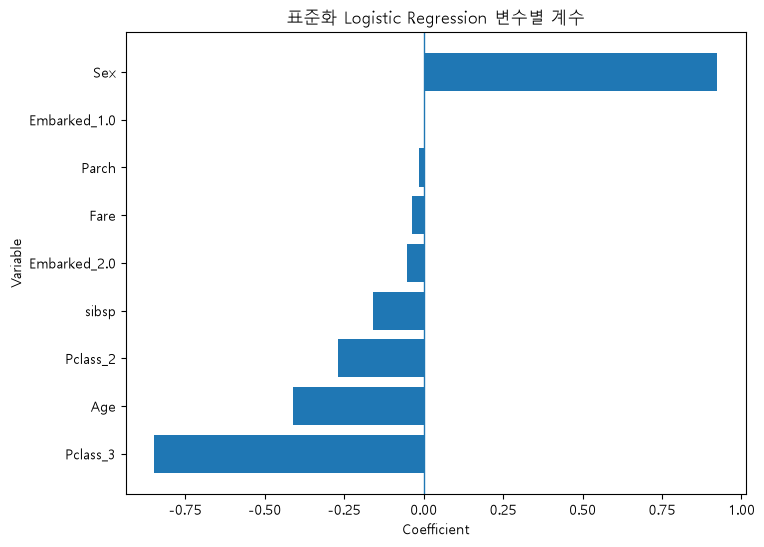

In [76]:
scaled_coef = scaled_model.named_steps["logistic"].coef_[0]

scaled_importance = pd.DataFrame({
    "변수": X.columns,
    "계수": scaled_coef
})

scaled_importance = scaled_importance.sort_values(
    "계수",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    scaled_importance["변수"],
    scaled_importance["계수"]
)

plt.title("표준화 Logistic Regression 변수별 계수")
plt.xlabel("Coefficient")
plt.ylabel("Variable")

plt.axvline(
    x=0,
    linewidth=1
)

plt.show()

In [77]:
df.groupby("Sex")["Survived"].mean()

KeyError: 'Column not found: Survived'

In [78]:
df_clean.groupby("Sex")["Survived"].mean()

Sex
0    0.1293
1    0.5000
Name: Survived, dtype: float64

In [79]:
sex_survival = df_clean.groupby("Sex")["Survived"].agg(
    승객수="count",
    생존자수="sum",
    생존율="mean"
)

sex_survival

,승객수,생존자수,생존율
Sex,,,
0,843,109,0.1293
1,466,233,0.5000


In [80]:
df_clean.groupby("Sex")["Survived"].mean()

Sex
0    0.1293
1    0.5000
Name: Survived, dtype: float64

In [81]:
df_clean.groupby("Sex")["Survived"].agg(["count", "sum", "mean"])

,count,sum,mean
Sex,,,
0,843,109,0.1293
1,466,233,0.5000


In [82]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest 학습 완료")

Random Forest 학습 완료


In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest 학습 완료")

Random Forest 학습 완료


In [84]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0]


In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("생존 Precision:",
      precision_score(y_test, y_pred_rf))

print("생존 Recall:",
      recall_score(y_test, y_pred_rf))

print("생존 F1:",
      f1_score(y_test, y_pred_rf))

print("\n[Classification Report]")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["사망", "생존"]
    )
)

Random Forest Accuracy: 0.7480916030534351
생존 Precision: 0.5108695652173914
생존 Recall: 0.6911764705882353
생존 F1: 0.5875

[Classification Report]
              precision    recall  f1-score   support

          사망       0.88      0.77      0.82       194
          생존       0.51      0.69      0.59        68

    accuracy                           0.75       262
   macro avg       0.69      0.73      0.70       262
weighted avg       0.78      0.75      0.76       262



In [86]:
model_comparison = pd.DataFrame({
    "모델": [
        "기본 Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_rf)
    ],

    "생존 Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_rf)
    ],

    "생존 Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_rf)
    ],

    "생존 F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,모델,Accuracy,생존 Precision,생존 Recall,생존 F1
0,기본 Logistic Regression,0.744275,0.510638,0.352941,0.417391
1,Balanced Logistic Regression,0.698473,0.447619,0.691176,0.543353
2,Random Forest,0.748092,0.510870,0.691176,0.587500


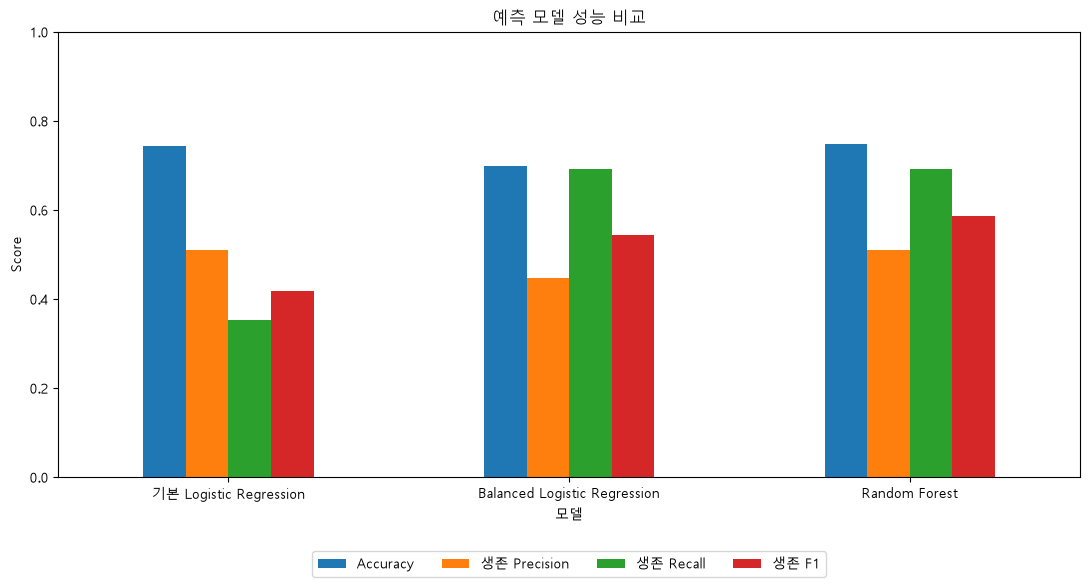

In [87]:
model_comparison.set_index("모델")[
    ["Accuracy", "생존 Precision", "생존 Recall", "생존 F1"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("예측 모델 성능 비교")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4
)

plt.tight_layout()
plt.show()

In [88]:
rf_importance = pd.DataFrame({
    "변수": X.columns,
    "중요도": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "중요도",
    ascending=True
)

rf_importance

,변수,중요도
5,Embarked_1.0,0.009304
6,Embarked_2.0,0.015919
7,Pclass_2,0.018975
3,sibsp,0.038418
4,Parch,0.045433
8,Pclass_3,0.104331
0,Age,0.134472
1,Fare,0.208067
2,Sex,0.425081


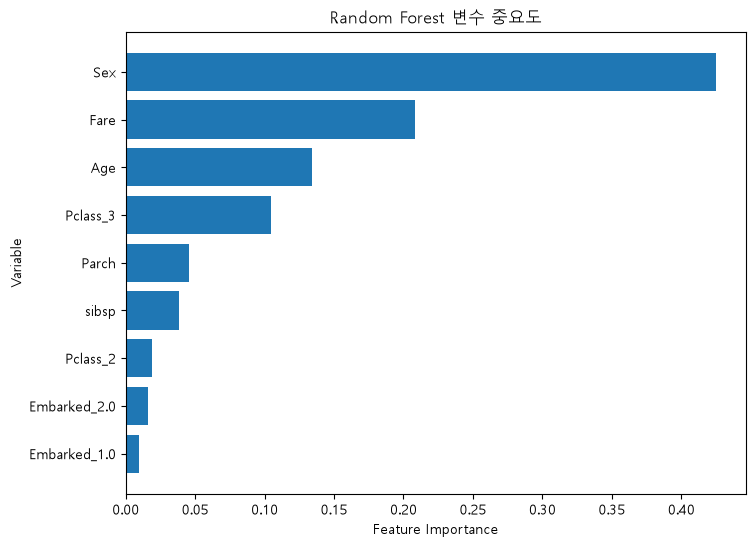

In [89]:
plt.figure(figsize=(8, 6))

plt.barh(
    rf_importance["변수"],
    rf_importance["중요도"]
)

plt.title("Random Forest 변수 중요도")
plt.xlabel("Feature Importance")
plt.ylabel("Variable")

plt.show()

[[149  45]
 [ 21  47]]


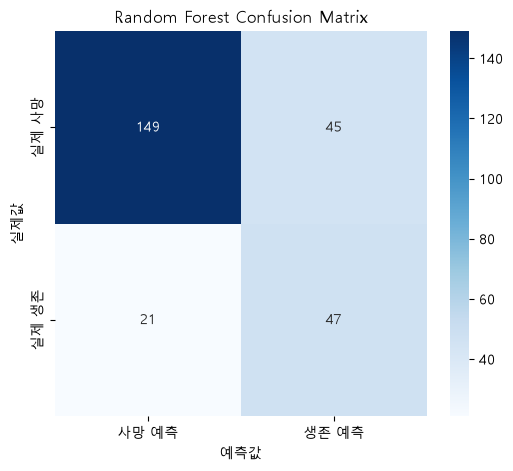

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["사망 예측", "생존 예측"],
    yticklabels=["실제 사망", "실제 생존"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("예측값")
plt.ylabel("실제값")

plt.show()

In [91]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("5-Fold Cross Validation 결과")
print("Accuracy 평균:", rf_cv["test_accuracy"].mean())
print("Precision 평균:", rf_cv["test_precision"].mean())
print("Recall 평균:", rf_cv["test_recall"].mean())
print("F1 평균:", rf_cv["test_f1"].mean())

5-Fold Cross Validation 결과
Accuracy 평균: 0.7425579830949665
Precision 평균: 0.5082455388447442
Recall 평균: 0.7193094629156009
F1 평균: 0.5926889229938455
